In [1]:
# Imports and setup

import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Add src/ to Python path so we can import our modules
notebook_dir = Path.cwd()
project_root = notebook_dir.parent  # assignment_2/
sys.path.insert(0, str(project_root / "src"))

# Verify paths
print("Notebook dir:", notebook_dir)
print("Project root:", project_root)
print("Data dir:    ", project_root / "data" / "raw")


Notebook dir: /Users/francescoorma99/Documents/GitHub/RES-Assignments/assignment_2/notebooks
Project root: /Users/francescoorma99/Documents/GitHub/RES-Assignments/assignment_2
Data dir:     /Users/francescoorma99/Documents/GitHub/RES-Assignments/assignment_2/data/raw


In [2]:
# Load raw data and sanity-check

from data_loader import load_all

raw = load_all(data_dir=project_root / "data" / "raw")

print("Wind capacity factor:")
print(f"  shape: {raw.wind_cf.shape}, range: [{raw.wind_cf.min():.3f}, {raw.wind_cf.max():.3f}], mean: {raw.wind_cf.mean():.3f}")
print(f"  index: {raw.wind_cf.index[0]} → {raw.wind_cf.index[-1]}")
print()

print("DA prices (EUR/MWh):")
print(f"  shape: {raw.da_prices.shape}, range: [{raw.da_prices.min():.2f}, {raw.da_prices.max():.2f}], mean: {raw.da_prices.mean():.2f}")
print(f"  index: {raw.da_prices.index[0]} → {raw.da_prices.index[-1]}")
print()

print("Imbalance:")
print(f"  shape: {raw.imbalance.shape}")
print(f"  columns: {list(raw.imbalance.columns)}")
print(f"  index: {raw.imbalance.index[0]} → {raw.imbalance.index[-1]}")
print()
print(raw.imbalance.describe())

Wind capacity factor:
  shape: (8760,), range: [0.000, 0.939], mean: 0.265
  index: 2024-01-01 00:00:00+00:00 → 2024-12-30 23:00:00+00:00

DA prices (EUR/MWh):
  shape: (8760,), range: [-59.96, 936.31], mean: 70.97
  index: 2024-01-01 00:00:00 → 2024-12-30 23:00:00

Imbalance:
  shape: (8760, 3)
  columns: ['mFRRUpActBal', 'mFRRDownActBal', 'ImbalanceMWh']
  index: 2024-01-01 00:00:00 → 2024-12-30 23:00:00

       mFRRUpActBal  mFRRDownActBal  ImbalanceMWh
count   8760.000000     8760.000000   8760.000000
mean       5.860360        9.814498   -121.936998
std       27.773364       29.500083    215.530390
min        0.000000        0.000000  -1265.000000
25%        0.000000        0.000000   -220.749996
50%        0.000000        0.000000   -105.649997
75%        0.000000        0.000000    -18.200001
max      537.000000      349.250000   1128.599976


In [3]:
# Build scenarios and sanity-check

from scenario_generation import build_scenarios, estimate_imbalance_p

p_hat = estimate_imbalance_p(raw.imbalance)
print(f"Estimated Bernoulli p = {p_hat:.3f}")
print()

S = build_scenarios(raw, n_wind=20, n_price=20, n_imb=4, P_nom=500.0, master_seed=42)

print(f"ScenarioSet:")
print(f"  n_scenarios = {S.n_scenarios}")
print(f"  n_hours     = {S.n_hours}")
print(f"  P_nom       = {S.P_nom} MW")
print(f"  prob/scen   = {S.probabilities[0]:.6f}  (sum = {S.probabilities.sum():.4f})")
print()

print("Wind production [MW]:")
print(f"  shape: {S.wind.shape}")
print(f"  range: [{S.wind.min():.1f}, {S.wind.max():.1f}]")
print(f"  mean:  {S.wind.mean():.1f}")
print()

print("DA prices [EUR/MWh]:")
print(f"  shape: {S.price_da.shape}")
print(f"  range: [{S.price_da.min():.2f}, {S.price_da.max():.2f}]")
print(f"  mean:  {S.price_da.mean():.2f}")
print()

print("Imbalance (binary):")
print(f"  shape: {S.imbalance.shape}")
print(f"  unique values: {np.unique(S.imbalance)}")
print(f"  fraction of '1' (deficit hours): {S.imbalance.mean():.3f}")

Estimated Bernoulli p = 0.344

ScenarioSet:
  n_scenarios = 1600
  n_hours     = 24
  P_nom       = 500.0 MW
  prob/scen   = 0.000625  (sum = 1.0000)

Wind production [MW]:
  shape: (1600, 24)
  range: [7.8, 420.5]
  mean:  140.9

DA prices [EUR/MWh]:
  shape: (1600, 24)
  range: [-40.77, 340.00]
  mean:  78.44

Imbalance (binary):
  shape: (1600, 24)
  unique values: [0 1]
  fraction of '1' (deficit hours): 0.312


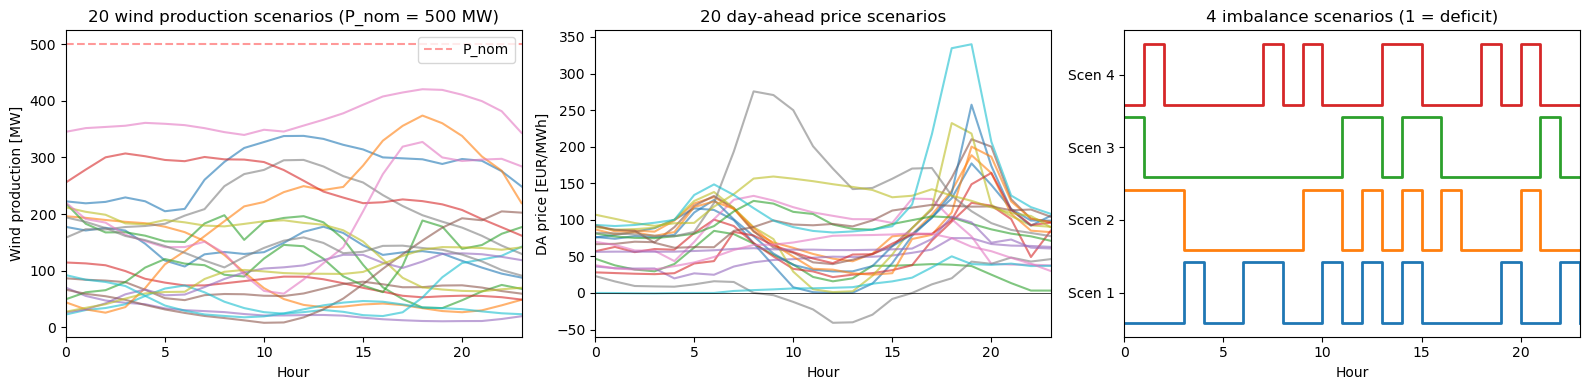

In [4]:
# Scenarios plot
 
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
hours = np.arange(24)

# Wind production scenarios (the 20 unique wind trajectories)
for w in S.wind_unique:
    axes[0].plot(hours, w, alpha=0.6)
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Wind production [MW]")
axes[0].set_title(f"20 wind production scenarios (P_nom = {S.P_nom:.0f} MW)")
axes[0].set_xlim(0, 23)
axes[0].axhline(S.P_nom, color="red", linestyle="--", alpha=0.4, label="P_nom")
axes[0].legend()

# DA price scenarios (the 20 unique price trajectories)
for p in S.price_unique:
    axes[1].plot(hours, p, alpha=0.6)
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("DA price [EUR/MWh]")
axes[1].set_title("20 day-ahead price scenarios")
axes[1].set_xlim(0, 23)
axes[1].axhline(0, color="black", linewidth=0.5)

# Imbalance scenarios (the 4 unique binary trajectories)
for i, imb in enumerate(S.imbalance_unique):
    axes[2].step(hours, imb + i * 1.2, where="post", linewidth=2)
axes[2].set_xlabel("Hour")
axes[2].set_yticks([0.5 + i * 1.2 for i in range(4)])
axes[2].set_yticklabels([f"Scen {i+1}" for i in range(4)])
axes[2].set_title("4 imbalance scenarios (1 = deficit)")
axes[2].set_xlim(0, 23)

plt.tight_layout()
plt.show()

# Task 1.1

In [5]:
# Task 1.1 — One-price offering strategy

from task1_1_offering_oneprice import OneprcInputData, StochasticOfferingOnePrice
data_1p = OneprcInputData(S)
model_1p = StochasticOfferingOnePrice(data_1p)
res_1p = model_1p.run(verbose=False)

print()
print("Task 1.1 — One-price offering strategy")
print()
print(f"Expected profit: {res_1p.expected_profit:,.2f} EUR")
print(f"Objective value: {res_1p.objective_value:,.2f} EUR  (checks that the expected profit is correctly computed as the objective value)")
print()
print("Hourly DA offers [MW]:")
for t, p in enumerate(res_1p.p_DA):
    print(f"  Hour {t:2d}: {p:7.2f} MW")
print()
print(f"Profit distribution across 1600 scenarios:")
print(f"  min:    {res_1p.profit_per_scenario.min():,.2f} EUR")
print(f"  median: {np.median(res_1p.profit_per_scenario):,.2f} EUR")
print(f"  mean:   {res_1p.profit_per_scenario.mean():,.2f} EUR")
print(f"  max:    {res_1p.profit_per_scenario.max():,.2f} EUR")
print(f"  std:    {res_1p.profit_per_scenario.std():,.2f} EUR")

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2817868
Academic license 2817868 - for non-commercial use only - registered to s2___@dtu.dk

Task 1.1 — One-price offering strategy

Expected profit: 311,093.77 EUR
Objective value: 311,093.77 EUR  (checks that the expected profit is correctly computed as the objective value)

Hourly DA offers [MW]:
  Hour  0:    0.00 MW
  Hour  1:    0.00 MW
  Hour  2:  500.00 MW
  Hour  3:  500.00 MW
  Hour  4:  500.00 MW
  Hour  5:  500.00 MW
  Hour  6:  500.00 MW
  Hour  7:    0.00 MW
  Hour  8:  500.00 MW
  Hour  9:    0.00 MW
  Hour 10:    0.00 MW
  Hour 11:  500.00 MW
  Hour 12:    0.00 MW
  Hour 13:  500.00 MW
  Hour 14:    0.00 MW
  Hour 15:  500.00 MW
  Hour 16:  500.00 MW
  Hour 17:  500.00 MW
  Hour 18:  500.00 MW
  Hour 19:  500.00 MW
  Hour 20:    0.00 MW
  Hour 21:  500.00 MW
  Hour 22:  500.00 MW
  Hour 23:  500.00 MW

Profit distribution across 1600 scenarios:
  min:    -4,229.98 EUR
  median: 261,831.36

# Task 1.2

### Two-price offering strategy

The two-price scheme settles excess and shortfall imbalances at different prices depending on the wind farm's contribution to the system imbalance. 

In hours with negative DA prices, our `TwoprcInputData` collapses the scheme to a uniform balancing settlement to avoid LP degeneracy (see the module docstring of `task1_2_offering_twoprice.py`). 

The diagnostic counters confirm the model has no well-posed complementarity violations.


Offering strategy — two-price

Expected profit:      256,720.98 EUR
Objective value:      256,720.98 EUR  (sanity check)

Hourly DA offers [MW]:
  Hour  0:   86.43 MW
  Hour  1:   83.85 MW
  Hour  2:  175.22 MW
  Hour  3:  167.80 MW
  Hour  4:  361.08 MW
  Hour  5:  359.45 MW
  Hour  6:  141.62 MW
  Hour  7:   85.20 MW
  Hour  8:  500.00 MW
  Hour  9:   92.62 MW
  Hour 10:   85.39 MW
  Hour 11:  152.91 MW
  Hour 12:   31.58 MW
  Hour 13:  177.58 MW
  Hour 14:   20.43 MW
  Hour 15:  144.74 MW
  Hour 16:  127.74 MW
  Hour 17:  500.00 MW
  Hour 18:  153.12 MW
  Hour 19:  175.82 MW
  Hour 20:  113.46 MW
  Hour 21:  145.19 MW
  Hour 22:  144.18 MW
  Hour 23:  500.00 MW

Profit distribution across scenarios:
  min:            -370.22 EUR
  median:      204,224.10 EUR
  mean:        256,720.98 EUR
  max:       1,184,428.52 EUR
  std:         206,194.46 EUR

Complementarity violations:    0 cells (well-posed bug check)
Harmless degenerate cells:     538 cells (psi_up == psi_dn, in negative-pr

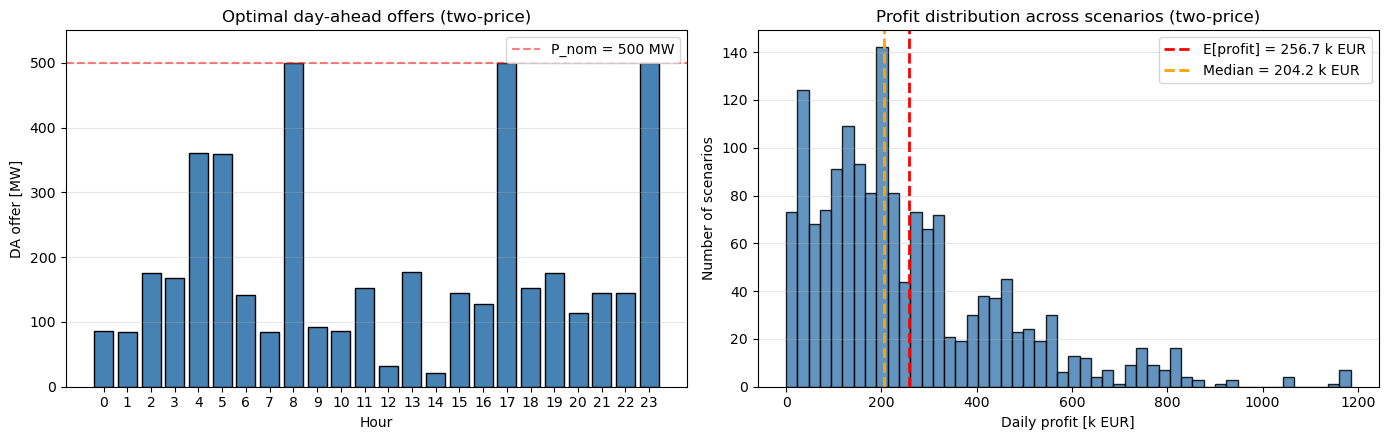

In [6]:
# Cell: Task 1.2 — Two-price offering strategy

from task1_2_offering_twoprice import TwoprcInputData, StochasticOfferingTwoPrice
from reporting import print_offering_summary, plot_offering_results

data_2p = TwoprcInputData(S)
res_2p = StochasticOfferingTwoPrice(data_2p).run()

print_offering_summary(res_2p, scheme_name="two-price")
print(f"\nComplementarity violations:    {res_2p.complementarity_violations} cells (well-posed bug check)")
print(f"Harmless degenerate cells:     {res_2p.harmless_degenerate_cells} cells (psi_up == psi_dn, in negative-price hours)")

fig, _ = plot_offering_results(res_2p, scheme_name="two-price", P_nom=S.P_nom)
plt.show()